## Algorithm Of Colorimetry

## Import Libraries

In [1]:
import colour
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## Separación de Muestras

In [ ]:
#Carga de los datos
input_filename = 'test-UN-21-11-25.csv'
data = pd.read_csv(input_filename)

#Extraer las longitudes de onda 'Wavelength (nm)'
wavelengths = data.iloc[1:, 0]

#Extraer las reflectancias de cada muestra 'Reflectances (%R)'
reflectances = data.iloc[1:, 1::2]

#Unir todo en un nuevo DataFrame
master_data = pd.concat([wavelengths, reflectances], axis=1)
num_samples = master_data.shape[1] - 1

#Asignamos los nombres al DataFrame
new_columns = ['Wavelength (nm)'] + [f'Reflectance POS {i} (%R)' for i in range(num_samples)]
master_data.columns = new_columns

#Todo lo que sea texto (el reporte del final) se convertirá en NaN (Not a Number) y se elimina
master_data['Wavelength (nm)'] = pd.to_numeric(master_data['Wavelength (nm)'], errors='coerce')
master_data = master_data.dropna(subset=['Wavelength (nm)'])

#Guardar datos procesados
base_name = os.path.splitext(input_filename)[0]
output_filename = f"{base_name}_processed.csv"
master_data.to_csv(output_filename, index=False)
print(f'Archivo procesado guardado con nombre {output_filename}')

Archivo procesado guardado con nombre test-UN-21-11-25_processed.csv


## View Data

## Raw Data

In [38]:
data.head()

,POS0,Unnamed: 1,POS1,Unnamed: 3,POS2,Unnamed: 5,POS3,Unnamed: 7,POS4,Unnamed: 9,...,Unnamed: 117,POS59,Unnamed: 119,POS60,Unnamed: 121,POS61,Unnamed: 123,POS62,Unnamed: 125,Unnamed: 126
0,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,...,%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,NaN
1,1099.98584,15.21335793,1099.98584,2.04280138,1099.98584,2.495107651,1099.98584,10.45411491,1099.98584,8.0770998,...,9.073075294,1099.98584,11.66044807,1099.98584,8.172636032,1099.98584,15.4112978,1099.98584,4.504504204,NaN
2,1098.986816,1.933050513,1098.986816,4.87804842,1098.986816,4.737091541,1098.986816,6.857424736,1098.986816,4.693308353,...,19.52227783,1098.986816,12.63304043,1098.986816,10.09401321,1098.986816,8.961593628,1098.986816,11.60714245,NaN
3,1097.987305,4.689593792,1097.987305,6.627326488,1097.987305,-1.085972905,1097.987305,8.194506645,1097.987305,4.984560966,...,6.389776707,1097.987305,9.634703636,1097.987305,13.62586594,1097.987305,12.63657951,1097.987305,14.78016853,NaN
4,1096.987061,5.391467571,1096.987061,7.142857552,1096.987061,-0.4055880904,1096.987061,3.135888577,1096.987061,4.537205219,...,11.26997471,1096.987061,13.4104538,1096.987061,11.89189148,1096.987061,13.14237595,1096.987061,12.91611195,NaN


## Processing Data

In [39]:
master_data.head()

,Wavelength (nm),Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),...,Reflectance POS 53 (%R),Reflectance POS 54 (%R),Reflectance POS 55 (%R),Reflectance POS 56 (%R),Reflectance POS 57 (%R),Reflectance POS 58 (%R),Reflectance POS 59 (%R),Reflectance POS 60 (%R),Reflectance POS 61 (%R),Reflectance POS 62 (%R)
1,1099.985840,15.21335793,2.04280138,2.495107651,10.45411491,8.0770998,-0.732421875,8.196721077,1.707317114,4.695995808,...,5.237866402,11.18258286,10.30977726,7.289185524,9.252157211,9.073075294,11.66044807,8.172636032,15.4112978,4.504504204
2,1098.986816,1.933050513,4.87804842,4.737091541,6.857424736,4.693308353,6.650485039,9.344423294,2.089136362,4.135338306,...,11.37633324,4.882629395,7.902439117,10.46780968,10.75268841,19.52227783,12.63304043,10.09401321,8.961593628,11.60714245
3,1097.987305,4.689593792,6.627326488,-1.085972905,8.194506645,4.984560966,7.884796619,4.263566017,7.527881145,3.937381506,...,4.220779419,10.61580849,7.963757992,13.72637272,12.45583057,6.389776707,9.634703636,13.62586594,12.63657951,14.78016853
4,1096.987061,5.391467571,7.142857552,-0.4055880904,3.135888577,4.537205219,6.233062267,7.858823299,4.015543938,3.800265074,...,6.090461254,10.95216751,5.710659981,10.10638332,13.70580482,11.26997471,13.4104538,11.89189148,13.14237595,12.91611195
5,1095.986084,9.882065773,0.6902502179,1.777970552,9.917713165,8.226539612,6.07202673,7.862819195,5.067567348,3.431372643,...,5.083996296,5.008143425,8.463541031,12.83422375,9.891435623,6.875805378,11.78465462,9.968425751,10.43553257,8.424599648


### Visualization of Spectrum

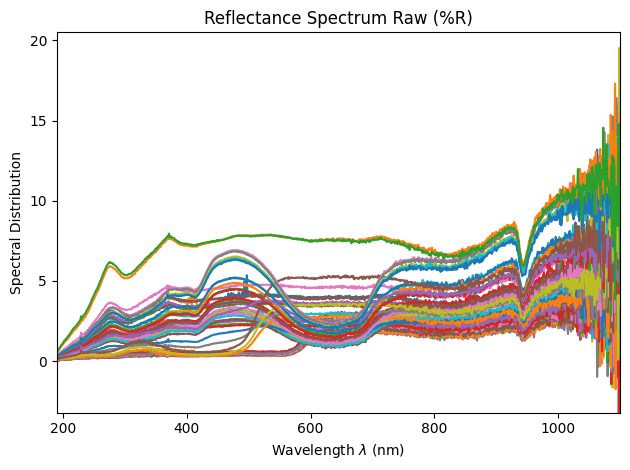

In [86]:
#Cargar datos
data_view = pd.read_csv('test-UN-21-11-25_processed.csv')

#Organizar los datos de forma ascendente
data_view = data_view.set_index('Wavelength (nm)')
data_view = data_view.sort_index()

#Crear el objeto con datos crudos (0-100)
msds_raw = colour.MultiSpectralDistributions(data_view)

#Graficar los espectros crudos
fig, ax = colour.plotting.plot_multi_sds(
    msds_raw,
    title='Reflectance Spectrum Raw (%R)',
    legend=False
)
plt.show()

## Preprocessing Data to Color Parameters

### Negative Reflectance

In [3]:
#Cargar datos procesados
data_processed = pd.read_csv('test-UN-21-11-25_processed.csv')

#Verificar si existen valores negativos
data_negatives = (data_processed< 0).stack()
data_negatives = data_negatives[data_negatives]

#Convertirlo a un Dataframe
data_negatives = data_negatives.reset_index()
data_negatives.columns = ['Row', 'Col', 'Is_negative']

#Obtener el valor negativo de Reflectancia
data_negatives['Reflectance (%R)'] = data_negatives.apply(
    lambda x: data_processed.loc[x['Row'], x['Col']], 
    axis=1
)

#Obtener el valor de la longitud de onda en donde hubo reflectancia negativa
wavelength_col = data_processed.columns[0]
data_negatives['Wavelength (nm)'] = data_negatives['Row'].apply(
    lambda r: data_processed.loc[r, wavelength_col]
)

print(data_negatives)

    Row                      Col  Is_negative  Reflectance (%R)  \
0     0   Reflectance POS 5 (%R)         True         -0.732422   
1     0  Reflectance POS 17 (%R)         True         -0.618557   
2     0  Reflectance POS 20 (%R)         True         -0.287494   
3     0  Reflectance POS 33 (%R)         True         -1.085418   
4     1  Reflectance POS 17 (%R)         True         -0.239120   
5     1  Reflectance POS 25 (%R)         True         -0.527072   
6     2   Reflectance POS 2 (%R)         True         -1.085973   
7     2  Reflectance POS 33 (%R)         True         -3.213958   
8     3   Reflectance POS 2 (%R)         True         -0.405588   
9     4  Reflectance POS 14 (%R)         True         -0.124792   
10    5  Reflectance POS 15 (%R)         True         -0.935374   
11    7  Reflectance POS 35 (%R)         True         -0.508011   
12    7  Reflectance POS 41 (%R)         True         -1.745539   
13    9  Reflectance POS 24 (%R)         True         -0.76539

### Set negative reflectance values to zero and normalize

In [4]:
#Crear una copia de los datos procesados
data_normalized = data_processed.copy(deep=True)
data_normalized = data_normalized.set_index('Wavelength (nm)')
data_normalized = data_normalized.sort_index(ascending=True)

#Cambiar los valores negativos a 0
data_normalized[data_normalized < 0] = 0

#Normalizar los % de reflectancia entre 100 (Factor de 0 a 1)
data_normalized = data_normalized / 100.0

In [4]:
data_normalized

,Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),Reflectance POS 9 (%R),...,Reflectance POS 53 (%R),Reflectance POS 54 (%R),Reflectance POS 55 (%R),Reflectance POS 56 (%R),Reflectance POS 57 (%R),Reflectance POS 58 (%R),Reflectance POS 59 (%R),Reflectance POS 60 (%R),Reflectance POS 61 (%R),Reflectance POS 62 (%R)
Wavelength (nm),,,,,,,,,,,,,,,,,,,,,
190.010590,0.002940,0.003004,0.002184,0.002596,0.002726,0.003153,0.003341,0.000754,0.000818,0.000753,...,0.002259,0.001887,0.001254,0.002967,0.002875,0.002987,0.002720,0.003031,0.005516,0.006096
191.000915,0.003062,0.003416,0.002663,0.002801,0.002820,0.003366,0.003760,0.000777,0.000447,0.000790,...,0.002332,0.002220,0.001452,0.003409,0.003660,0.003180,0.003251,0.003001,0.005650,0.006461
191.991165,0.003571,0.003600,0.002728,0.003292,0.003160,0.003691,0.004155,0.001097,0.000546,0.000673,...,0.002357,0.002154,0.001624,0.003790,0.003869,0.003659,0.003497,0.003511,0.006601,0.006996
192.981354,0.003674,0.003774,0.002934,0.003364,0.003446,0.003619,0.004706,0.000984,0.000814,0.000741,...,0.002556,0.002438,0.001477,0.004063,0.004077,0.003792,0.003831,0.003667,0.006870,0.007267
194.011063,0.004218,0.004180,0.003635,0.003632,0.003635,0.004150,0.004967,0.001206,0.000811,0.000828,...,0.002805,0.002369,0.001692,0.004526,0.004401,0.004241,0.004212,0.004158,0.007659,0.008343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095.986084,0.098821,0.006903,0.017780,0.099177,0.082265,0.060720,0.078628,0.050676,0.034314,0.062659,...,0.050840,0.050081,0.084635,0.128342,0.098914,0.068758,0.117847,0.099684,0.104355,0.084246
1096.987061,0.053915,0.071429,0.000000,0.031359,0.045372,0.062331,0.078588,0.040155,0.038003,0.035665,...,0.060905,0.109522,0.057107,0.101064,0.137058,0.112700,0.134105,0.118919,0.131424,0.129161
1097.987305,0.046896,0.066273,0.000000,0.081945,0.049846,0.078848,0.042636,0.075279,0.039374,0.101324,...,0.042208,0.106158,0.079638,0.137264,0.124558,0.063898,0.096347,0.136259,0.126366,0.147802


### Create MultiSpectralDistribution and XYZ Values

In [12]:
#Crear objeto
msds = colour.MultiSpectralDistributions(data_normalized)

#Verificamos la dimension y la forma de los espectros (Valor Max, Valor Min, Saltos)
print(msds.shape)
print(msds.domain[:5])

#Definimos nueva forma de nuestro espectro en el rango visible
shape = colour.SpectralShape(300, 800, 1)

#Interpolacion de los espectros para que los saltos sean de 1nm
msds = msds.align(shape)

#Cargar estandares de la CIE
cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
illuminant = colour.SDS_ILLUMINANTS['D65']

#Calculo XYZ
XYZ = colour.msds_to_XYZ(msds, cmfs, illuminant)

#Visualizar valores XYZ calculados
print("Dimensión de XYZ:", XYZ.shape)
print("Valores XYZ:\n", XYZ)

(190.0105896, 1099.98584, 0.9649047999999993)
[ 190.0105896  191.0009155  191.9911652  192.9813538  194.0110626]
Dimensión de XYZ: (63, 3)
Valores XYZ:
 [[ 3.80095207  4.07824599  4.30373048]
 [ 3.32852757  3.54862321  3.80067736]
 [ 3.30250678  3.52629335  3.74536262]
 [ 3.38723001  3.61677409  3.85050087]
 [ 3.43858966  3.66869543  3.91191827]
 [ 3.7341228   3.98461088  4.25688498]
 [ 4.3830612   4.68044071  4.97186731]
 [ 1.25485156  0.95337791  0.61089834]
 [ 1.16152451  0.83583565  0.47398699]
 [ 1.07397708  0.77334687  0.44381542]
 [ 1.1200154   0.80710074  0.45754171]
 [ 1.42429445  1.02325974  0.59533705]
 [ 1.43954125  1.04101815  0.58787184]
 [ 1.48715494  1.07555796  0.61021932]
 [ 0.88303457  0.64812383  0.3775109 ]
 [ 0.97694543  0.70841413  0.40516134]
 [ 1.00964853  0.73179232  0.41948133]
 [ 0.86831286  0.63182568  0.36778041]
 [ 0.97332372  0.70327208  0.4044824 ]
 [ 1.16192138  0.83006562  0.46947975]
 [ 1.2196318   0.88550597  0.50499025]
 [ 0.89997306  0.65222851  0

## Calculate CIELab (L* a* b*)

In [14]:
#Definir punto blanco para el iluminante D65
illuminant_xy = colour.CCS_ILLUMINANTS['CIE 1931 2 Degree Standard Observer']['D65']

#Usamos los valores XYZ para calcular CIELab
Lab = colour.XYZ_to_Lab(XYZ, illuminant=illuminant_xy)

#Visualizar valores Lab calculados
print('Valores CIELab calculados.')
print("Valores (L, a, b):\n", Lab)

Valores CIELab calculados.
Valores (L, a, b):
 [[ 169.33145212   -5.20260177    3.33733922]
 [ 160.93399581   -3.35236841    1.69276132]
 [ 160.56209307   -3.73311347    2.53046833]
 [ 162.05948659   -3.7659303     2.31339435]
 [ 162.907498     -3.58041298    2.16405772]
 [ 167.90207443   -3.72034422    2.02434594]
 [ 178.03805168   -4.12464757    2.76632819]
 [  98.16851473   56.4113788    31.89846243]
 [  93.26933166   63.57848941   36.82938428]
 [  90.47543768   61.8382054    35.29905369]
 [  92.0025238    62.59357528   36.41879799]
 [ 100.89249228   68.32417531   38.00756465]
 [ 101.56483069   67.46058376   39.85317808]
 [ 102.85093297   68.17922857   40.03273243]
 [  84.38696361   55.1838206    32.58748554]
 [  87.40790195   58.87884019   34.44638919]
 [  88.5331263    59.59754854   34.71135365]
 [  83.53834483   56.11514995   32.34196329]
 [  87.15709773   59.33556926   34.09436074]
 [  93.01731094   64.72566275   36.87682104]
 [  95.3922956    63.19734806   37.25458863]
 [  84.5

## Visualization of XYZ in sRGB


Valores sRGB listos para graficar


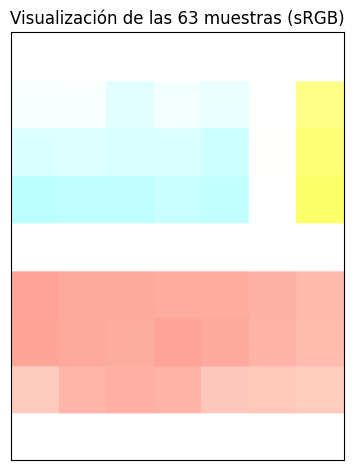

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Visualización de las 63 muestras (sRGB)'}>)

In [15]:
#Convertimos los tristimulos XYZ a un espacio sRGB
RGB = colour.XYZ_to_sRGB(XYZ, illuminant=illuminant_xy)

#Clipping o Recorte
RGB_clipped = np.clip(RGB, 0, 1)

print("\nValores sRGB listos para graficar")

#Graficar los colores RGB
colour.plotting.plot_multi_colour_swatches(
    RGB_clipped,
    title='Visualización de las 63 muestras (sRGB)',
    width=2.5,
    height=2.5,
    rows = 9,
    columns=7,
    text_kwargs={'size':'small'}
)

## Visualization of Lab in sRGB

In [ ]:
#Convertimos los tristimulos XYZ a un espacio sRGB
RGB = colour.Lab_to_sRGB(XYZ, illuminant=illuminant_xy)

#Clipping o Recorte
RGB_clipped = np.clip(RGB, 0, 1)

print("\nValores sRGB listos para graficar")

#Graficar los colores RGB
colour.plotting.plot_multi_colour_swatches(
    RGB_clipped,
    title='Visualización de las 63 muestras (sRGB)',
    width=2.5,
    height=2.5,
    columns=8,
    text_kwargs={'size':'small'}
)